In [39]:
from datasets import load_dataset
import numpy as np 
import mahotas as mh 
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import glob
from PIL import Image
from skimage.transform import pyramid_laplacian
from skimage.transform import pyramid_gaussian
import os

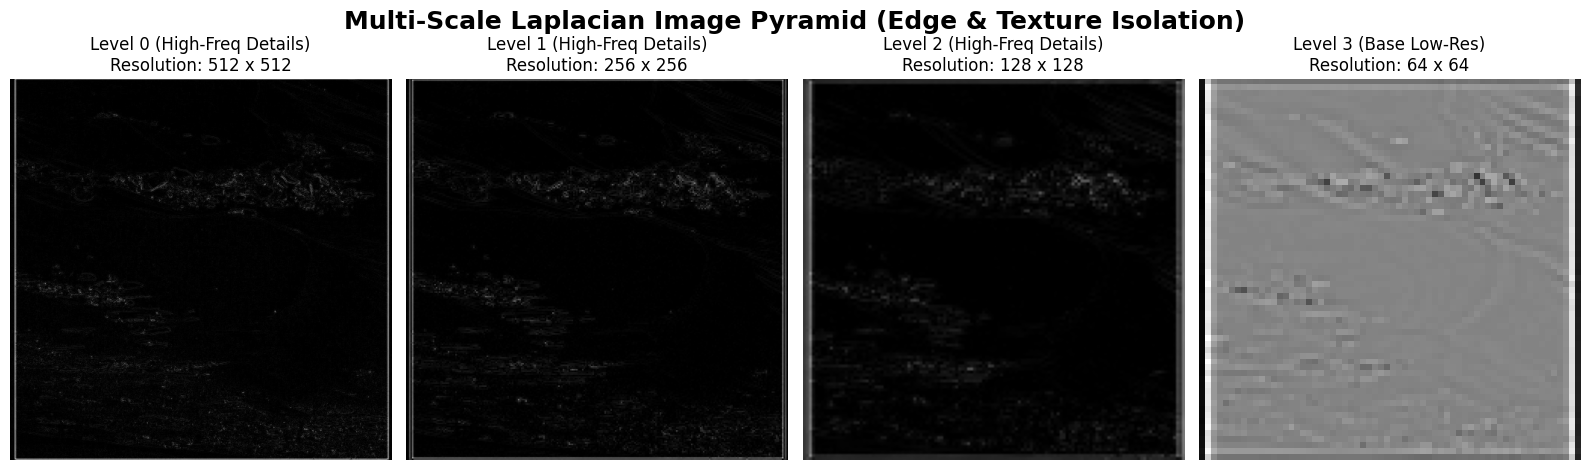

In [ ]:
image_path = "image.png"

try:
    img_pil = Image.open(image_path).convert('L').resize((512, 512))
    
    img_array = np.array(img_pil) / 255.0 
    
    pyramid = tuple(pyramid_laplacian(img_array, downscale=2, max_layer=3))
    
    fig, axes = plt.subplots(1, len(pyramid), figsize=(16, 5))
    fig.suptitle("Multi-Scale Laplacian Image Pyramid (Edge & Texture Isolation)", fontsize=18, fontweight='bold')
    
    for i, (ax, p_img) in enumerate(zip(axes, pyramid)):
        h, w = p_img.shape
        
        if i == len(pyramid) - 1:
            ax.imshow(p_img, cmap='gray')
            ax.set_title(f"Level {i} (Base Low-Res)\nResolution: {w} x {h}", fontsize=12)
        else:
            ax.imshow(np.abs(p_img), cmap='gray', vmax=0.2) 
            ax.set_title(f"Level {i} (High-Freq Details)\nResolution: {w} x {h}", fontsize=12)
            
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Could not find {image_path}. Please check the file name!")

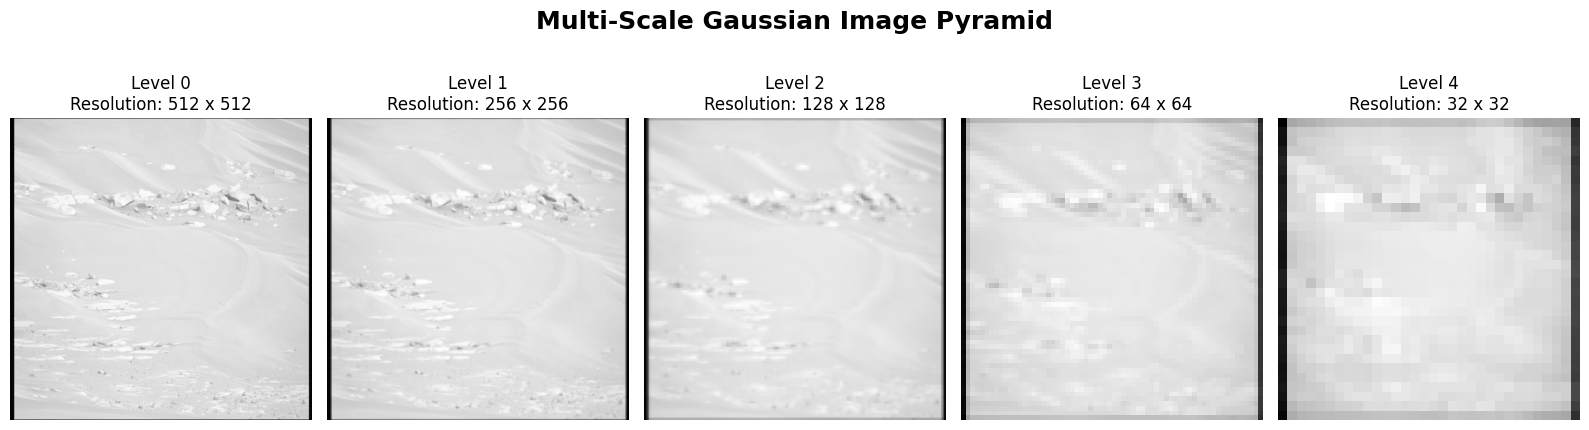

In [ ]:
image_path = "image.png"

try:
    img_pil = Image.open(image_path).convert('L').resize((512, 512))
    img_array = np.array(img_pil)
    
    pyramid = tuple(pyramid_gaussian(img_array, downscale=2, max_layer=4))
    
    fig, axes = plt.subplots(1, len(pyramid), figsize=(16, 5))
    fig.suptitle("Multi-Scale Gaussian Image Pyramid", fontsize=18, fontweight='bold')
    
    for i, (ax, p_img) in enumerate(zip(axes, pyramid)):
        ax.imshow(p_img, cmap='gray')
        
        h, w = p_img.shape
        ax.set_title(f"Level {i}\nResolution: {w} x {h}", fontsize=12)
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Could not find {image_path}. Please check the file name!")

In [ ]:
print("Connecting to Hugging Face securely...")

ds = load_dataset(
    "hassanjbara/AI4MARS", 
    split="train", 
    streaming=True, 
)

features_list = []
labels_list = []

print("Extracting MULTI-SCALE Haralick features from 5000 valid images...")

for example in ds:
    if example['label_mask'] is None:
        continue
        
    mask = np.array(example['label_mask'], dtype=np.int64).flatten()
    mask_filtered = mask[mask != 255] 
    
    if len(mask_filtered) == 0:
        continue
        
    dominant_class = np.argmax(np.bincount(mask_filtered))
    
    img = np.array(example['image'].convert('L'))
    
    # max_layer=2 yields 3 total images: (Original, 1/2 size, 1/4 size)
    pyramid = tuple(pyramid_gaussian(img, downscale=2, max_layer=2))
    
    multi_scale_features = []
    
    for level_img in pyramid:
        level_img_uint8 = (level_img * 255).astype(np.uint8)
        
        # Extract Haralick for this specific scale
        h_features = mh.features.haralick(level_img_uint8).mean(axis=0)
        
        # Select Energy, Contrast, Correlation, Entropy
        selected = h_features[[0, 1, 2, 8]]
        
        # Extend adds these 4 numbers to our list for the current image
        multi_scale_features.extend(selected)
    
    # Append the combined 12 features (4 features * 3 levels) to our main list
    features_list.append(multi_scale_features)
    
    labels_list.append(dominant_class)
    
    if len(features_list) % 250 == 0:
        print(f"Done: {len(features_list)}/5000")
        
    if len(features_list) == 5000:
        break

# 4. Final Data Preparation
X = np.array(features_list)
y = np.array(labels_list)

# 5. Scale all 12 multi-scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nReady! Data shape: {X_scaled.shape}")

Connecting to Hugging Face securely...
Extracting MULTI-SCALE Haralick features from 5000 valid images...
Grab a coffee, computing pyramids for 5000 images will take a few minutes!
Done: 250/5000
Done: 500/5000
Done: 750/5000
Done: 1000/5000
Done: 1250/5000
Done: 1500/5000
Done: 1750/5000
Done: 2000/5000
Done: 2250/5000
Done: 2500/5000
Done: 2750/5000
Done: 3000/5000
Done: 3250/5000
Done: 3500/5000
Done: 3750/5000
Done: 4000/5000
Done: 4250/5000
Done: 4500/5000
Done: 4750/5000
Done: 5000/5000

Ready! Data shape: (5000, 12)


In [63]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train model
print("Training Linear SVM model...")
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train, y_train)

# Run prediction on test set
y_pred = svm_model.predict(X_test)

# Results
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Training Linear SVM model...
Overall Accuracy: 75.20%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.72      0.76       348
           1       0.72      0.93      0.81       502
           2       0.81      0.25      0.38       137
           3       0.00      0.00      0.00        13

    accuracy                           0.75      1000
   macro avg       0.58      0.47      0.49      1000
weighted avg       0.75      0.75      0.73      1000



In [ ]:
class_names = {0: "Soil", 1: "Bedrock", 2: "Sand", 3: "Big Rock"}

def predict_custom_mars_data_pyramid(image_paths, trained_model, fitted_scaler):
    valid_images = []
    features_list = []
    
    print(f"Processing {len(image_paths)} custom images using Pyramid Features...")
    
    for path in image_paths:
        try:
            img_pil = Image.open(path).convert('L')
            
            # Resize to reduce computational complexity 
            img_pil = img_pil.resize((512, 512)) 
            img_array = np.array(img_pil)
            
            pyramid = tuple(pyramid_gaussian(img_array, downscale=2, max_layer=2))
            
            multi_scale_features = []
            
            for level_img in pyramid:
                # Convert float[0, 1] back to uint8[0, 255] for mahotas
                level_img_uint8 = (level_img * 255).astype(np.uint8)
                
                # Extract Haralick Features for this specific layer
                h_features = mh.features.haralick(level_img_uint8).mean(axis=0)
                selected = h_features[[0, 1, 2, 8]] # Energy, Contrast, Correlation, Entropy
                
                # Add these 4 features to our running list for this image
                multi_scale_features.extend(selected)

            features_list.append(multi_scale_features)
            
            valid_images.append(img_pil)
            
        except Exception as e:
            print(f"Could not process {path}: {e}")
            
    if not features_list:
        print("No valid images processed.")
        return
        
    X_custom = np.array(features_list)
    
    X_custom_scaled = fitted_scaler.transform(X_custom)
    
    # Predict
    predictions = trained_model.predict(X_custom_scaled)
    
    # Visualization
    num_images = len(valid_images)
    fig, axes = plt.subplots(1, num_images, figsize=(4 * num_images, 4))
    
    if num_images == 1:
        axes = [axes]
        
    for i, ax in enumerate(axes):
        ax.imshow(valid_images[i], cmap='gray')
        pred_label = class_names.get(predictions[i], f"Class {predictions[i]}")
        ax.set_title(f"SVM Thinks:\n{pred_label}", fontsize=14, fontweight='bold')
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

Found image! Processing...
Processing 1 custom images using Pyramid Features...


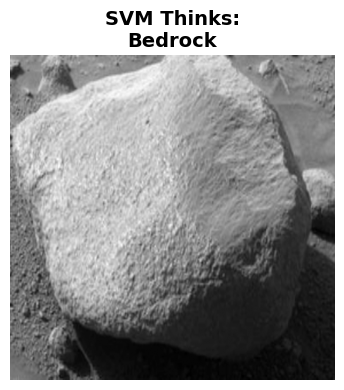

In [ ]:
image_path = r"rocks.png"

if os.path.exists(image_path):
    print(f"Found image! Processing...")
    
    predict_custom_mars_data_pyramid([image_path], svm_model, scaler)
    
else:
    print(f"Image not found at: {image_path}")
    print("Check if the path and file name are exactly correct.")